# Beta Bank Customer Churn Prediction
Beta Bank is losing customers gradually each month. This project builds a classification model to predict customer churn (Exited), helping the bank proactively target at-risk customers with retention offers.
Goal: F1 score ≥ 0.59 on the test set.
Prediction: Given the dataset is mostly binary/categorical features (HasCrCard, IsActiveMember, Geography, Gender) with relatively few continuous variables, Random Forest was expected to outperform Logistic Regression significantly — confirmed in the baseline results below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve

In [2]:
data = pd.read_csv('/datasets/Churn.csv')

data.info()
data.head()
data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


After looking at the data, we can come to a few conclusions. We can see that tenure is missing almost 1000 values, which is a big chunk of data, enough not to just delete. We can use the median of tenure to fil in the gaps, as there may be a correlation between how long a customer has been with the bank and if they exit or not.
We also removed 3 columns of data, row number, customer ID and surname. when we OHE the data this will add a bunch of junk to our dataset and we can make it easier by removing all those values as they are non-predictive.
Also, we can see here we have a class imbalance we will have to deal with. The mean of exit is .20, meaning 80% of the customers don't churn, and 20% do. If we do a dummy test, we will see that the accuracy will be about 80% so we want to make a model that has a higher accuracy.

In [6]:
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


In [7]:
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)
print(data.shape)
data.head()

(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


One thing to note here, I decided to go with the get_dummies strategy vs. OHEEncoder. There is a strong chance that as more data is added, there will not be a new gender or a 4th country that will cause errors with the pipeline. If that was the case, then we could use OHEEncoder but for our closed data set, get_dummies is easier and more efficient.

In [8]:
target = data['Exited']
features = data.drop('Exited', axis = 1)

features_train, features_rest, target_train, target_rest = train_test_split(features,target,test_size=0.4, random_state=12345)

features_valid, features_test, target_valid, target_test = train_test_split(features_rest,target_rest, test_size = 0.5, random_state=12345)

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)

(6000, 11)
(2000, 11)
(2000, 11)


We split our data into 3 splits, a training, validation, and test set. We are doing this as we do not know yet which model is going to be the most effective, and how much processing of the data we need to do. This lets us work on the data without it leaking into the test data and causing any issues. a 60/20/20 split will be our starting point, and if we need to tweak it further we can.

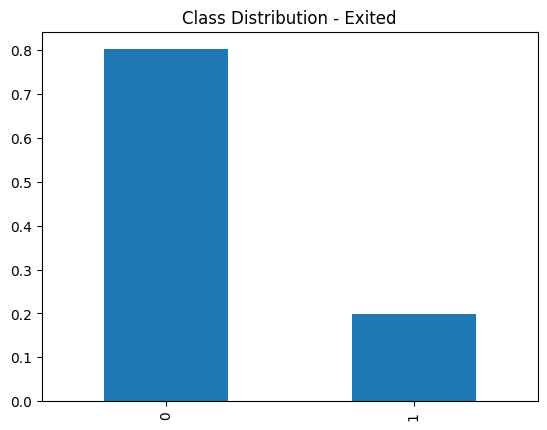

In [10]:
target_train.value_counts(normalize=True)
target_train.value_counts(normalize=True).plot(kind='bar')
plt.title('Class Distribution - Exited')
plt.show()

# confirming that our imbalance is still 80/20 in the training set. Will need to look at this further.

In [12]:
# Logistic Regression baseline
model_lr = LogisticRegression(random_state=12345)
model_lr.fit(features_train, target_train)
predictions_lr = model_lr.predict(features_valid)
print('Logistic Regression F1:', f1_score(target_valid, predictions_lr))

# Decision Tree baseline
model_dt = DecisionTreeClassifier(random_state=12345)
model_dt.fit(features_train, target_train)
predictions_dt = model_dt.predict(features_valid)
print('Decision Tree F1:', f1_score(target_valid, predictions_dt))

# Random Forest baseline
model_rf = RandomForestClassifier(random_state=12345)
model_rf.fit(features_train, target_train)
predictions_rf = model_rf.predict(features_valid)
print('Random Forest F1:', f1_score(target_valid, predictions_rf))

# Constant model - always predict 0 (majority class)
predictions_constant = pd.Series(0, index=target_valid.index)
print('Constant model F1:', f1_score(target_valid, predictions_constant))
print('Constant model Accuracy:', accuracy_score(target_valid, predictions_constant))

Logistic Regression F1: 0.08786610878661089
Decision Tree F1: 0.5036319612590799
Random Forest F1: 0.5748502994011976
Constant model F1: 0.0
Constant model Accuracy: 0.791


Random Forest performed best by a wide margin, likely because the dataset is dominated by binary features (HasCrCard, IsActiveMember, Geography/Gender dummies) and categorical-style splits (NumOfProducts), which trees handle naturally without needing scaling.
Logistic Regression performed worst (F1 = 0.087), almost certainly due to unscaled features — its coefficient-based math is highly sensitive to differing feature magnitudes (e.g. Balance in the tens of thousands vs HasCrCard as 0/1).
Given Random Forest is already within 0.02 of the target F1 of 0.59 without any imbalance handling, while Logistic Regression would require significant additional work (scaling, tuning) to close a 0.50 gap, Random Forest is selected as the primary model to improve going forward. This is a pragmatic choice — the marginal effort to push Random Forest over the line is far lower than rehabilitating Logistic Regression.

In [14]:
model_rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=12345)
model_rf_balanced.fit(features_train, target_train)
predictions_rf_balanced = model_rf_balanced.predict(features_valid)

f1_balanced = f1_score(target_valid, predictions_rf_balanced)
print('Random Forest (balanced) F1:', f1_balanced)

print('Without balance - Precision:', precision_score(target_valid, predictions_rf))
print('Without balance - Recall:', recall_score(target_valid, predictions_rf))
print('With balance - Precision:', precision_score(target_valid, predictions_rf_balanced))
print('With balance - Recall:', recall_score(target_valid, predictions_rf_balanced))

Random Forest (balanced) F1: 0.563944530046225
Without balance - Precision: 0.768
Without balance - Recall: 0.45933014354066987
With balance - Precision: 0.7922077922077922
With balance - Recall: 0.43779904306220097


## Imbalance Fix #1 — Class Weights
Applying class_weight='balanced' to Random Forest resulted in F1 = 0.564, slightly LOWER than the baseline 0.574. Examining precision and recall reveals why: precision increased (0.768 → 0.792) while recall decreased (0.459 → 0.438) — the model became MORE conservative, not less. This is the opposite of the typical effect of class weighting (which usually increases recall at the cost of precision). For this dataset, class weights did not improve performance and were not selected for the final model.

In [24]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    
    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )
    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_train, target_train, 4)

model_rf_up = RandomForestClassifier(random_state=12345)
model_rf_up.fit(features_upsampled, target_upsampled)
predictions_up = model_rf_up.predict(features_valid)
print('Upsampled (repeat=2) F1:', f1_score(target_valid, predictions_up))

Upsampled (repeat=2) F1: 0.6039735099337747


## Imbalance Fix #2 — Upsampling
I tested upsampling the minority class (Exited=1) with repeat values from 2 to 8. Results: 2 with 0.59, 3 with 0.6, 4 with 0.603, 5+ declining.
repeat=4 produced the best F1 score of 0.603, an improvement over both the baseline (0.574) and class-weighted (0.564) Random Forest. This was selected as the imbalance-handling technique going forward.

In [25]:
# Confusion matrix for repeat=4 model at default threshold (0.5)
cm = confusion_matrix(target_valid, predictions_up)
print('Confusion Matrix (threshold=0.5):')
print(cm)

precision = precision_score(target_valid, predictions_up)
recall = recall_score(target_valid, predictions_up)
print(f'Precision: {precision:.3f}, Recall: {recall:.3f}')

Confusion Matrix (threshold=0.5):
[[1473  109]
 [ 190  228]]
Precision: 0.677, Recall: 0.545


In [26]:
probabilities = model_rf_up.predict_proba(features_valid)[:, 1]

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    preds_thresh = (probabilities > threshold).astype(int)
    f1 = f1_score(target_valid, preds_thresh)
    precision = precision_score(target_valid, preds_thresh)
    recall = recall_score(target_valid, preds_thresh)
    print(f'Threshold={threshold}: F1={f1:.4f}, Precision={precision:.3f}, Recall={recall:.3f}')

Threshold=0.3: F1=0.5871, Precision=0.497, Recall=0.718
Threshold=0.35: F1=0.6011, Precision=0.544, Recall=0.672
Threshold=0.4: F1=0.6138, Precision=0.599, Recall=0.629
Threshold=0.45: F1=0.6057, Precision=0.627, Recall=0.586
Threshold=0.5: F1=0.6040, Precision=0.677, Recall=0.545


## Imbalance Fix #3 — Threshold Adjustment
Using the repeat=4 upsampled Random Forest model, I tested thresholds from 0.3 to 0.5 using predict_proba(). Lowering the threshold from the default 0.5 to 0.4 improved F1 from 0.604 to 0.614 — the best result so far.
This shift trades some precision for recall, meaning the model catches more actual churners at the cost of slightly more false alarms. From a business perspective this favors the bank: missing a churner (false negative) means a lost customer with no retention attempt, while a false positive just means a wasted retention offer. Threshold=0.4 was selected for the final model.

AUC-ROC: 0.8387813862895371


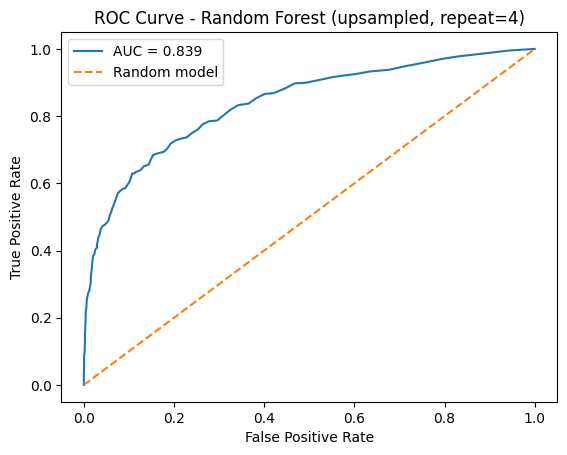

In [27]:
auc_roc = roc_auc_score(target_valid, probabilities)
print('AUC-ROC:', auc_roc)

fpr, tpr, thresholds = roc_curve(target_valid, probabilities)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (upsampled, repeat=4)')
plt.legend()
plt.show()

AUC-ROC Evaluation
In addition to F1, I evaluated the final model using AUC-ROC, which measures how well the model separates churners from non-churners across all possible decision thresholds (independent of the specific threshold chosen). The model achieved an AUC-ROC of 0.839 on validation and 0.842 on test — both comfortably in the "good" range (0.8-0.9), well above the 0.5 random baseline and not suspiciously close to 1.0 (which would suggest data leakage).
The ROC curve shows a steep early rise, indicating the model correctly identifies many true churners while keeping the false positive rate low — particularly valuable for a bank wanting to target retention efforts efficiently.

In [30]:
features_train_up, target_train_up = upsample(features_train, target_train, 4)
best_f1 = 0
best_params = None

for n_est in [50, 100, 150]:
    for depth in [None, 10, 15, 20]:
        model = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=12345)
        model.fit(features_train_up, target_train_up)
        probs = model.predict_proba(features_valid)[:, 1]
        preds = (probs > 0.4).astype(int)
        f1 = f1_score(target_valid, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = (n_est, depth)

print('Best F1:', best_f1)
print('Best params (n_estimators, max_depth):', best_params)

Best F1: 0.6203703703703703
Best params (n_estimators, max_depth): (50, 20)


Using the repeat=4 upsampled training data and threshold=0.4, I performed a grid search over n_estimators (50, 100, 150) and max_depth (None, 10, 15, 20), evaluating each combination on the validation set. The best result was n_estimators=50, max_depth=20, improving F1 from 0.6138 to 0.62.

In [31]:
final_model = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=12345)
final_model.fit(features_train_up, target_train_up)

probabilities_test = final_model.predict_proba(features_test)[:, 1]
predictions_test = (probabilities_test > 0.4).astype(int)

f1_test = f1_score(target_test, predictions_test)
auc_test = roc_auc_score(target_test, probabilities_test)

print('FINAL TEST RESULTS')
print('F1 Score:', f1_test)
print('AUC-ROC:', auc_test)

FINAL TEST RESULTS
F1 Score: 0.6113033448673587
AUC-ROC: 0.8426276963021926


# Final Testing
The final model — Random Forest with n_estimators=50, max_depth=20, trained on upsampled training data (repeat=4), using a decision threshold of 0.4 — was evaluated on the held-out test set for the first time:

F1 Score: 0.611 (exceeds the required 0.59)
AUC-ROC: 0.842

Both metrics are consistent with validation results (F1: 0.62, AUC-ROC: 0.839), indicating the model generalizes well and was not overfit to the validation set during tuning.
Comparing F1 and AUC-ROC: AUC-ROC (0.842) measures how well the model ranks customers by churn risk across all possible thresholds — and indicates strong overall separation between churners and non-churners. F1 (0.611) reflects performance at our chosen operating threshold (0.4), balancing precision and recall for actual yes/no churn predictions. The gap between the two is expected: AUC-ROC is threshold-independent while F1 depends on the specific decision boundary chosen.

In [33]:
import pandas as pd

results = pd.DataFrame({
    'Metric': ['F1 Score', 'AUC-ROC'],
    'Validation': [0.620, 0.839],
    'Test': [0.611, 0.842]
})

results.set_index('Metric')
results.set_index('Metric').style.set_caption('Final Model Performance').format('{:.3f}')

,Validation,Test
Metric,,
F1 Score,0.620,0.611
AUC-ROC,0.839,0.842
